In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import re

In [2]:
df = pd.read_csv('../Data/CRX_fulllength_unified.csv')

No Change vs SLiM Removed: t=-4.9456, p=7.9353e-07
No Change vs SLiM Added: t=5.1967, p=2.1512e-07


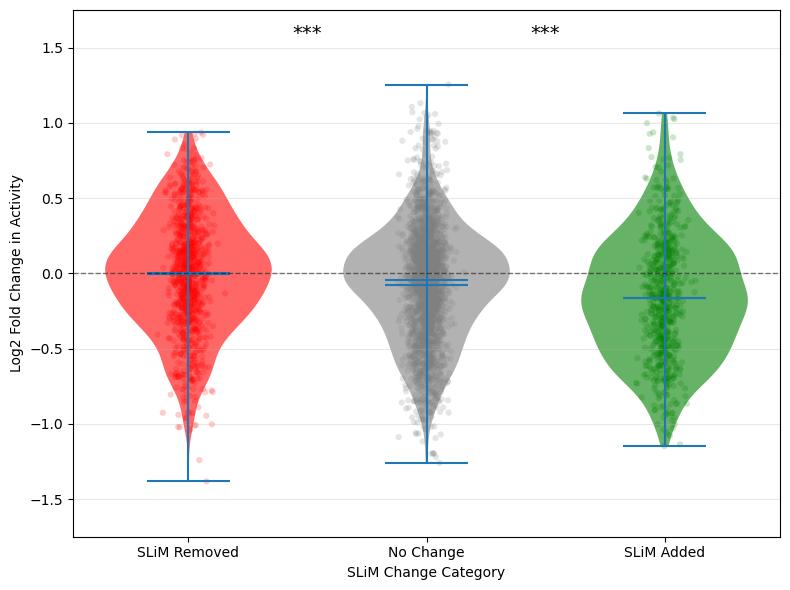

In [3]:
# Categorize mutations based on SLiM changes
# Allow multiple categories per row
def get_slim_categories(row):
    categories = []
    if row['SLiM_removed'] > 0:
        categories.append('SLiM Removed')
    if row['SLiM_added'] > 0:
        categories.append('SLiM Added')
    if row['SLiM_removed'] == 0 and row['SLiM_added'] == 0:
        categories.append('No Change')
    return categories

# Create the violin plot
fig, ax = plt.subplots(figsize=(8, 6))

# Prepare data for each category
categories = ['SLiM Removed', 'No Change', 'SLiM Added']
colors = ['red', 'grey', 'green']

# Collect data allowing duplicates and convert to log2 fold change
data = [[], [], []]
for idx, row in df.iterrows():
    cats = get_slim_categories(row)
    score = row['normalized_activity_score_mean']
    if pd.notna(score) and score > 0:  # Ensure positive value for log
        log2_fc = np.log2(score)
        for cat in cats:
            data[categories.index(cat)].append(log2_fc)

# Perform t-tests
# No Change vs SLiM Removed
t_stat_removed, p_val_removed = stats.ttest_ind(data[1], data[0])
# No Change vs SLiM Added
t_stat_added, p_val_added = stats.ttest_ind(data[1], data[2])

print(f"No Change vs SLiM Removed: t={t_stat_removed:.4f}, p={p_val_removed:.4e}")
print(f"No Change vs SLiM Added: t={t_stat_added:.4f}, p={p_val_added:.4e}")

# Create violin plot
parts = ax.violinplot(data, positions=[1, 2, 3], widths=0.7, showmeans=True, showmedians=True)

# Color the violins
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

# Add raw data points with jitter
np.random.seed(42)  # For reproducibility
for i, (dataset, color) in enumerate(zip(data, colors)):
    # Add jitter to x-coordinates
    x_jitter = np.random.normal(i + 1, 0.04, size=len(dataset))
    ax.scatter(x_jitter, dataset, alpha=0.2, s=20, color=color, edgecolors='none')

# Add horizontal line at y=0 (no change)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add significance annotations
y_max = max([max(d) for d in data]) + 0.1
if p_val_removed < 0.001:
    ax.text(1.5, y_max + 0.2, '***', ha='center', fontsize=14)
elif p_val_removed < 0.01:
    ax.text(1.5, y_max + 0.2, '**', ha='center', fontsize=14)
elif p_val_removed < 0.05:
    ax.text(1.5, y_max + 0.2, '*', ha='center', fontsize=14)

if p_val_added < 0.001:
    ax.text(2.5, y_max + 0.2, '***', ha='center', fontsize=14)
elif p_val_added < 0.01:
    ax.text(2.5, y_max + 0.2, '**', ha='center', fontsize=14)
elif p_val_added < 0.05:
    ax.text(2.5, y_max + 0.2, '*', ha='center', fontsize=14)

# Customize appearance
ax.set_ylim(-1.75, 1.75)
ax.set_ylabel('Log2 Fold Change in Activity')
ax.set_xlabel('SLiM Change Category')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(categories)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/s5/pmcccnjn3xscf5d6crplwgx40000gn/T/ipykernel_28067/3788009414.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=categories, patch_artist=True, widths=0.6)


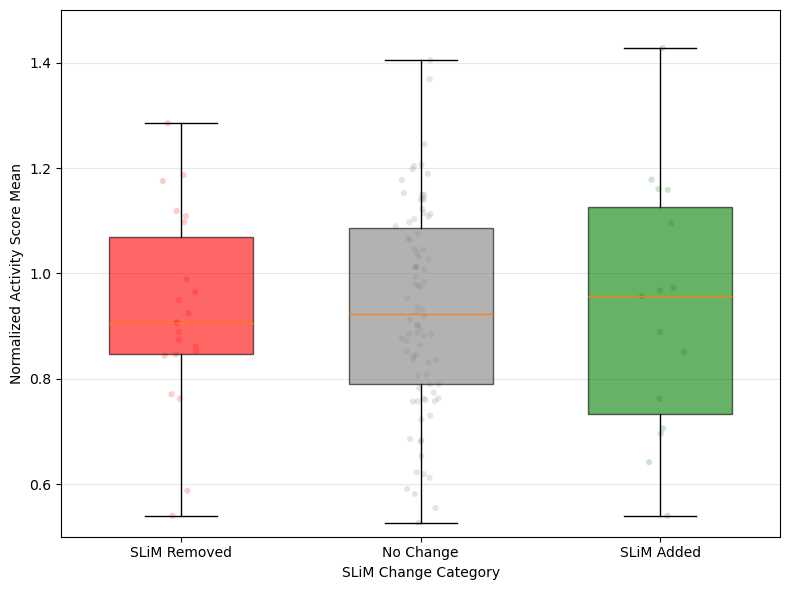

In [5]:
# Categorize mutations based on SLiM changes (only for in_clinvar == True)
# Allow multiple categories per row
def get_slim_categories(row):
    categories = []
    if row['SLiM_removed'] > 0:
        categories.append('SLiM Removed')
    if row['SLiM_added'] > 0:
        categories.append('SLiM Added')
    if row['SLiM_removed'] == 0 and row['SLiM_added'] == 0:
        categories.append('No Change')
    return categories

# Filter for only clinvar entries
df_clinvar = df[df['in_clinvar'] == True].copy()

# Create the boxplot
fig, ax = plt.subplots(figsize=(8, 6))

# Prepare data for each category
categories = ['SLiM Removed', 'No Change', 'SLiM Added']
colors = ['red', 'grey', 'green']

# Collect data allowing duplicates
data = [[], [], []]
for idx, row in df_clinvar.iterrows():
    cats = get_slim_categories(row)
    score = row['normalized_activity_score_mean']
    if pd.notna(score):
        for cat in cats:
            data[categories.index(cat)].append(score)

# Create boxplot
bp = ax.boxplot(data, labels=categories, patch_artist=True, widths=0.6)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Add raw data points with jitter
np.random.seed(42)  # For reproducibility
for i, (dataset, color) in enumerate(zip(data, colors)):
    # Add jitter to x-coordinates
    x_jitter = np.random.normal(i + 1, 0.04, size=len(dataset))
    ax.scatter(x_jitter, dataset, alpha=0.2, s=20, color=color, edgecolors='none')

# Customize appearance
ax.set_ylim(.5, 1.5)
ax.set_ylabel('Normalized Activity Score Mean')
ax.set_xlabel('SLiM Change Category')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()